# Model Performance Visualization

This notebook compares the trained surrogate model predictions against the generated simulation data. It creates a 3D plot of Surface Area vs X Cell Size and YZ Cell Size at a fixed inlet velocity, showing both data points and model-predicted surface. Additional diagnostic plots (parity and residual histogram) are included.

In [13]:
# Imports
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from sklearn.metrics import r2_score, mean_squared_error
import os

In [14]:
# Paths to artifacts
DATA_CSV = os.path.join('nTop', 'Generated Data.csv')
MODEL_PKL = 'trained_model.pkl'
SCALER_X_PKL = 'scaler_X.pkl'
SCALER_Y_PKL = 'scaler_y.pkl'

# Load data
df = pd.read_csv(DATA_CSV)
print('Loaded data shape:', df.shape)
print('Columns:', df.columns.tolist())

Loaded data shape: (1000, 7)
Columns: ['AvgVelocity', 'Mass', 'PressureDrop', 'Surface Area', 'Velocity Inlet', 'X Cell Size', 'YZ Cell Size']


In [15]:
# Load model and scalers
with open(MODEL_PKL, 'rb') as f:
    model = pickle.load(f)
with open(SCALER_X_PKL, 'rb') as f:
    scaler_X = pickle.load(f)
with open(SCALER_Y_PKL, 'rb') as f:
    scaler_y = pickle.load(f)

print('Model and scalers loaded successfully')

Model and scalers loaded successfully


## Select a single inlet velocity
We'll pick a representative inlet velocity from the dataset. If a value does not exist exactly in the data, we'll pick the closest available value.

In [16]:
# Inspect unique inlet velocities
unique_vel = np.unique(df['Velocity Inlet'].values)
print('Number of unique inlet velocities in data:', unique_vel.size)
print('Sample velocities (first 10):', unique_vel[:10])

# Choose a representative inlet velocity. We'll use 3055.555556 if present, otherwise choose the median available value.
preferred = 2500
if preferred in unique_vel:
    chosen_velocity = preferred
else:
    chosen_velocity = float(unique_vel[len(unique_vel)//2])

Number of unique inlet velocities in data: 10
Sample velocities (first 10): [2500.       2611.111111 2722.222222 2833.333333 2944.444444 3055.555556
 3166.666667 3277.777778 3388.888889 3500.      ]


In [17]:
# Filter the data to the chosen inlet velocity (allow a small tolerance)
tol = 1e-6
mask = np.isclose(df['Velocity Inlet'].values.astype(float), chosen_velocity, atol=tol)
df_slice = df[mask].copy()
if df_slice.empty:
    # If exact match not found, pick closest velocity
    closest = unique_vel[np.argmin(np.abs(unique_vel - chosen_velocity))]
    print('Exact velocity not found, using closest available:', closest)
    mask = np.isclose(df['Velocity Inlet'].values.astype(float), closest, atol=1e-3)
    df_slice = df[mask].copy()
print('Rows in selected slice:', len(df_slice))

# Training used features = ['X Cell Size', 'YZ Cell Size', 'Velocity Inlet'] (see train.ipynb).
# We must construct inputs in the same column order before applying scaler_X.
training_feature_order = ['X Cell Size', 'YZ Cell Size', 'Velocity Inlet']

# Build a grid over X and YZ cell sizes using the unique values from the dataset slice
x_vals = np.unique(df_slice['X Cell Size'].values.astype(float))
yz_vals = np.unique(df_slice['YZ Cell Size'].values.astype(float))
Xg, Yg = np.meshgrid(x_vals, yz_vals, indexing='xy')

# Flatten grid and create input DataFrame in the training feature order
# Note training order is X, YZ, Velocity; grid_points columns must match that
grid_points = np.column_stack([Xg.ravel(), Yg.ravel(), np.full(Xg.size, chosen_velocity)])

grid_df = pd.DataFrame(grid_points, columns=training_feature_order)
print('Grid shape:', grid_df.shape)

# Scale inputs, predict, inverse transform outputs
X_scaled = scaler_X.transform(grid_df)
y_scaled = model.predict(X_scaled, verbose=0)
y_pred = scaler_y.inverse_transform(y_scaled)

# Extract surface area predictions (assumes order ['PressureDrop','AvgVelocity','Surface Area','Mass'])
surface_pred = y_pred[:, 2].reshape(Xg.shape)

# Get measured surface area from data slice aligned to grid (by matching X and YZ values)
measured_surface = np.full_like(surface_pred, np.nan, dtype=float)
for i, xi in enumerate(x_vals):
    for j, yzi in enumerate(yz_vals):
        # find row with matching X and YZ (and chosen velocity)
        row = df_slice[(np.isclose(df_slice['X Cell Size'].astype(float), xi)) & (np.isclose(df_slice['YZ Cell Size'].astype(float), yzi))]
        if not row.empty:
            measured_surface[j, i] = row['Surface Area'].values[0]

print('Prepared prediction and measured surfaces')

Rows in selected slice: 100
Grid shape: (100, 3)
Prepared prediction and measured surfaces


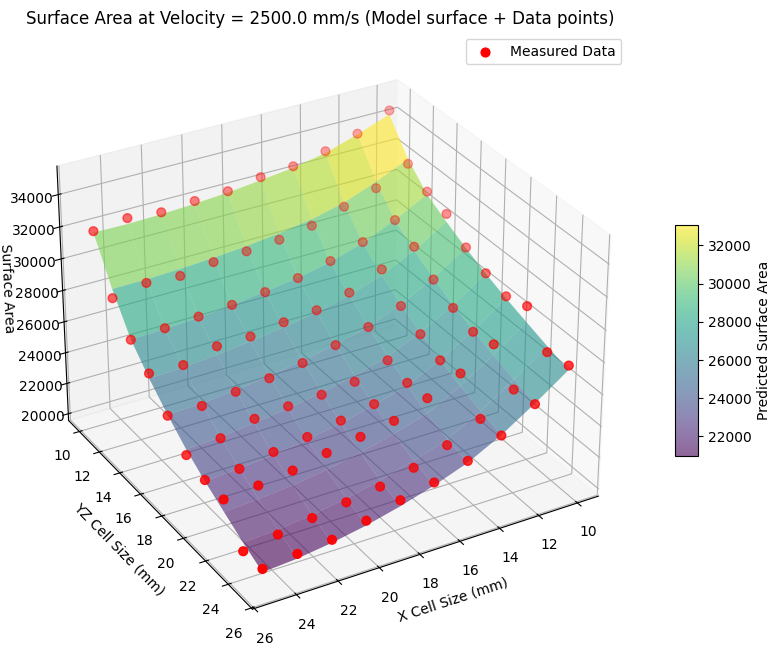

Points compared: 100 | R2: 0.9878 | RMSE: 373.9463


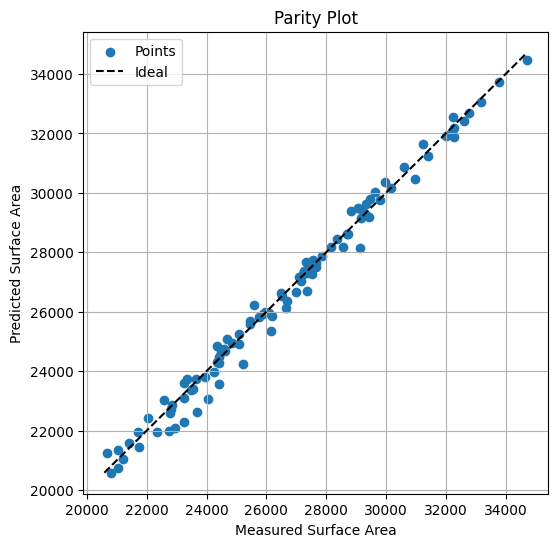

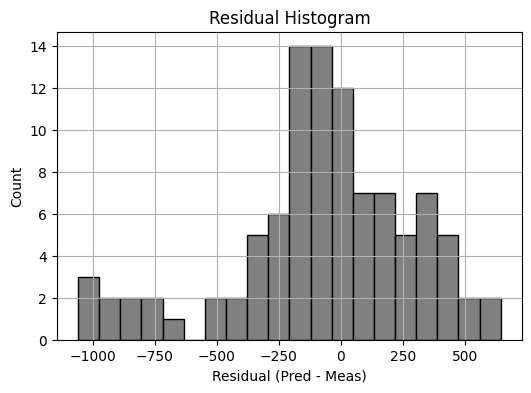

In [21]:
# 3D plot: model surface vs measured data points
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
# Plot model-predicted surface
surf = ax.plot_surface(Xg, Yg, surface_pred, cmap=cm.viridis, alpha=0.6, linewidth=0, antialiased=True)
# Plot measured data points where available
mask_meas = ~np.isnan(measured_surface)
ax.scatter(Xg[mask_meas], Yg[mask_meas], measured_surface[mask_meas], color='r', s=40, label='Measured Data')
ax.set_xlabel('X Cell Size (mm)')
ax.set_ylabel('YZ Cell Size (mm)')
ax.set_zlabel('Surface Area')
ax.set_title(f'Surface Area at Velocity = {chosen_velocity:.1f} mm/s (Model surface + Data points)')
fig.colorbar(surf, shrink=0.375, aspect=10, label='Predicted Surface Area')
ax.view_init(elev=30, azim=60)
ax.legend()
plt.show()

# Parity plot and residuals
# Build matched lists of measured vs predicted for points where measured exists
meas = measured_surface[mask_meas]
pred = surface_pred[mask_meas]
if len(meas) > 0:
    r2 = r2_score(meas, pred)
    rmse = np.sqrt(mean_squared_error(meas, pred))
    print(f'Points compared: {len(meas)} | R2: {r2:.4f} | RMSE: {rmse:.4f}')

    plt.figure(figsize=(6,6))
    plt.scatter(meas, pred, c='tab:blue', label='Points')
    mn = min(meas.min(), pred.min())
    mx = max(meas.max(), pred.max())
    plt.plot([mn, mx], [mn, mx], 'k--', label='Ideal')
    plt.xlabel('Measured Surface Area')
    plt.ylabel('Predicted Surface Area')
    plt.title('Parity Plot')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Residual histogram
    residuals = pred - meas
    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=20, color='gray', edgecolor='k')
    plt.xlabel('Residual (Pred - Meas)')
    plt.ylabel('Count')
    plt.title('Residual Histogram')
    plt.grid(True)
    plt.show()
else:
    print('No measured points found for the chosen velocity to compute parity metrics.')